# LightGBM — Hyperparameter Tuning + Training
1. Runs hyperparamter tuning study using **RandomSearchCV** for each of 4 objectives (RMSE, MAE, Huber, Quantile) on a **2.5% stratified sample**
2. Records the best hyperparameters per objective
3. Runs a **5-fold StratifiedKFold CV** on the full training data using each objective's best params
4. Produces a **4 × 4 comparison table** (rows = objectives, columns = RMSE / MAE / Huber / Quantile)

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
#import glob

import datagen as gen

import lightgbm as lgb
from lightgbm import LGBMRegressor

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error as mae,
    root_mean_squared_error as rmse,
    make_scorer,
    mean_pinball_loss,
)
from scipy.special import huber

## 2. Config

In [ ]:
#DATA_PATH  = glob.glob("/Volumes/T7/common_training_data/*.csv")
TARGET_RAW = "LENGTH_OF_STAY"
SEED       = 42
TEST_SIZE  = 0.20

# CV N_SPLITS for StratifiedKFold
N_SPLITS_FINAL = 5
# Keeps 2.5% of training data for GridSearchCV (hyperparameter tuning)
TUNE_KEEP_FRAC = 0.025

# Categorical Features
CAT_FEATURES = [
    "SEX_CODE", "RACE", "ETHNICITY", "ADMIT_WEEKDAY", "PAT_RURAL",
    "PROVIDER_RURAL", "EMERGENCY_DEPT_FLAG"
]

#All Features
FEATURES = CAT_FEATURES.copy()
FEATURES.extend([
    "PAT_AGE", "CODE_1",  "CODE_2",  "CODE_3",
    "CODE_4", "CODE_5", "CODE_6",  "CODE_7",  "CODE_8",
    "CODE_9", "CODE_10", "CODE_11", "CODE_12", "CODE_13",
    "CODE_14", "CODE_15", "CODE_16", "CODE_17", "CODE_18",
    "CODE_19", "CODE_20", "CODE_21", "CODE_22", "PAT2PROV_DISTANCE",
    "PAT_LATITUDE", "PAT_LONGITUDE", "PROVIDER_LATITUDE", "PROVIDER_LONGITUDE",
    "NUM_CODES"
])

# Hyperparameter grid
PARAM_GRID = {
    "max_depth":     [6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05],
    "reg_lambda":    [3, 5, 10],
    "subsample":     [0.6, 0.8, 1.0],
}

# Fixed LightGBM params (not tuned)
LGBM_FIXED = dict(
    n_estimators     = 250,
    num_leaves       = 127,
    min_child_samples= 100,
    subsample_freq   = 1,
    colsample_bytree = 0.8,
    n_jobs           = -1,
    random_state     = SEED,
    verbose = -1
)

# Huber delta -- match CatBoost notebook (delta=2.0)
HUBER_DELTA = 2.0

# Prolonged-stay quantile determined after importing data.
QUANTILE_ALPHA = None

print(f"Feature count    = {len(FEATURES)}")

Feature count    = 36


## 3. Metric helpers

In [56]:
def huber_loss(y_true, y_pred, delta=HUBER_DELTA):
    r = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return float(np.mean(np.where(r <= delta, 0.5 * r**2, delta * (r - 0.5 * delta))))

huber_scorer = make_scorer(huber_loss, delta=HUBER_DELTA, greater_is_better=False)

print("Metric helpers defined.")

Metric helpers defined.


## 4. Load & prepare data

In [ ]:
#Loads in data files
print("Loading data...")
df = gen.load_training_data()

Loading data...


In [58]:
#Creates column for number of diagnostic codes
df["NUM_CODES"] = df[[f"CODE_{i}" for i in range(1, 23)]].sum(axis=1)

#Creates column for log of target log(LENGTH_OF_STAY)
df["log_LOS"]  = np.log1p(df[TARGET_RAW])

# Prolonged-stay quantile (percentile of LOS <= 30 days) -- mirrors CatBoost notebook
QUANTILE_ALPHA = df.loc[df[TARGET_RAW] <= 30].shape[0] / df.shape[0]

print(f"Rows             : {len(df):,}")
print(f"Strata           : {df['STRATA'].value_counts().to_dict()}")
print(f"Target skew -- raw: {df[TARGET_RAW].skew():.3f}   log1p: {df['log_LOS'].skew():.3f}")
print(f"Prolonged-stay quantile (LOS <= 30 days): {QUANTILE_ALPHA:.6f}")

Rows             : 5,605,266
Strata           : {'4_0_0': 1220041, '1_0_0': 1216810, '3_0_0': 1191422, '2_0_0': 1176826, '1_1_0': 144184, '4_1_0': 143472, '3_1_0': 141206, '2_1_0': 140426, '1_1_1': 55350, '4_1_1': 53404, '3_1_1': 53208, '2_1_1': 51849, '1_0_1': 4406, '3_0_1': 4322, '4_0_1': 4250, '2_0_1': 4090}
Target skew -- raw: 157.479   log1p: 1.202
Prolonged-stay quantile (LOS <= 30 days): 0.987532


## 5. Train / test split

In [59]:
X     = df[FEATURES].copy()
y     = df["log_LOS"].copy()
y_raw = df[TARGET_RAW].copy()

X_train, X_test, y_train, y_test, y_raw_train, y_raw_test = train_test_split(
    X, y, y_raw,
    test_size    = TEST_SIZE,
    stratify     = df["STRATA"],
    random_state = SEED,
    shuffle = True
)

X_train[CAT_FEATURES] = X_train[CAT_FEATURES].astype("category")
X_test[CAT_FEATURES]  = X_test[CAT_FEATURES].astype("category")

strata_train = df.loc[X_train.index, "STRATA"]

print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")

Train: 4,484,212   Test: 1,121,054


## 6. Tuning sample (2.5% of training data, stratified)

In [60]:
X_tune_discard, X_tune_train, y_tune_discard, y_tune_train, y_raw_tune_discard, y_raw_tune_train = train_test_split(
    X_train, y_train, y_raw_train,
    test_size    = TUNE_KEEP_FRAC,
    stratify     = strata_train,
    random_state = SEED,
    shuffle = True
)

print(f"Tuning sample: {X_hyp_train.shape[0]:,} rows")


Tuning sample: 112,106 rows


## 7. Hyperparameter tuning — one RandomizedSearchCV per objective

Samples `N_ITER` random combinations per objective on the 2.5% tuning sample with 3-fold CV.
10 iterations × 4 objectives × 3 folds = 120 fits.

In [61]:
print(X_tune_train[CAT_FEATURES].dtypes)
print(X_tune_train[FEATURES].dtypes)

SEX_CODE               category
RACE                   category
ETHNICITY              category
ADMIT_WEEKDAY          category
PAT_RURAL              category
PROVIDER_RURAL         category
EMERGENCY_DEPT_FLAG    category
dtype: object
SEX_CODE               category
RACE                   category
ETHNICITY              category
ADMIT_WEEKDAY          category
PAT_RURAL              category
PROVIDER_RURAL         category
EMERGENCY_DEPT_FLAG    category
PAT_AGE                   int64
CODE_1                    int64
CODE_2                    int64
CODE_3                    int64
CODE_4                    int64
CODE_5                    int64
CODE_6                    int64
CODE_7                    int64
CODE_8                    int64
CODE_9                    int64
CODE_10                   int64
CODE_11                   int64
CODE_12                   int64
CODE_13                   int64
CODE_14                   int64
CODE_15                   int64
CODE_16                   

In [ ]:
N_ITER = 10  # number of random combinations to try per objective

# Encode categoricals as integer codes so dtype survives CV splitting in sklearn
X_tune_encoded = X_tune_train.copy()
for col in CAT_FEATURES:
    if col in X_tune_encoded.columns:
        X_tune_encoded[col] = X_tune_encoded[col].cat.codes

quantile_scorer = make_scorer(
    mean_pinball_loss,
    alpha=QUANTILE_ALPHA,
    greater_is_better=False,
)

# (label, LGBMRegressor objective kwargs, sklearn scorer for CV)
OBJECTIVES = [
    ("RMSE",     {"objective": "regression"},                          "neg_root_mean_squared_error"),
    ("MAE",      {"objective": "regression_l1"},                       "neg_mean_absolute_error"),
    ("Huber",    {"objective": "huber",    "alpha": 0.9},              huber_scorer),
    ("Quantile", {"objective": "quantile", "alpha": QUANTILE_ALPHA},   quantile_scorer),
]

best_params_per_obj = {}

for label, obj_kwargs, scorer in OBJECTIVES:
    print(f"\nHyperparameter tuning — {label}")
    print("-" * 50)

    model = LGBMRegressor(**LGBM_FIXED, **obj_kwargs)

    search = RandomizedSearchCV(
        estimator            = model,
        param_distributions  = PARAM_GRID,
        n_iter               = N_ITER,
        scoring              = scorer,
        cv                   = 3,
        n_jobs               = -1,
        random_state         = SEED,
        verbose              = 1,
    )
    search.fit(
        X_tune_encoded, y_tune_train
    )

    best_params_per_obj[label] = search.best_params_
    print(f"Best score : {search.best_score_:.4f}")
    print(f"Best params: {search.best_params_}")

print("\nTuning complete.")


Hyperparameter tuning — RMSE
--------------------------------------------------
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best score : -0.5531
Best params: {'subsample': 0.8, 'reg_lambda': 10, 'max_depth': 7, 'learning_rate': 0.05}

Hyperparameter tuning — MAE
--------------------------------------------------
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best score : -0.4064
Best params: {'subsample': 0.8, 'reg_lambda': 10, 'max_depth': 7, 'learning_rate': 0.05}

Hyperparameter tuning — Huber
--------------------------------------------------
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best score : -0.1532
Best params: {'subsample': 0.8, 'reg_lambda': 10, 'max_depth': 7, 'learning_rate': 0.05}

Hyperparameter tuning — Quantile
--------------------------------------------------
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best score : -0.0226
Best params: {'subsample': 0.8, 'reg_lambda': 3, 'max_depth': 6, 'learning_ra

## 8. Best hyperparameters per objective

In [63]:
best_df = pd.DataFrame(best_params_per_obj).T
best_df.index.name = "Objective"
print(best_df.to_string())

           subsample  reg_lambda  max_depth  learning_rate
Objective                                                 
RMSE             0.8        10.0        7.0           0.05
MAE              0.8        10.0        7.0           0.05
Huber            0.8        10.0        7.0           0.05
Quantile         0.8         3.0        6.0           0.03


## 9. Final 5-fold StratifiedKFold CV — full training data

Each objective trains with its tuned hyperparameters and early stopping re-enabled.

In [ ]:
skf = StratifiedKFold(n_splits=N_SPLITS_FINAL, shuffle=True, random_state=SEED)

scores = pd.DataFrame(
    0.0,
    index=["RMSE", "MAE", "Huber", "Quantile"],
    columns=["RMSE", "MAE", "Huber", "Quantile"]
)

for label, obj_kwargs, _ in OBJECTIVES:
    tuned  = best_params_per_obj[label]
    params = {**LGBM_FIXED, **obj_kwargs, **tuned, "n_estimators": 3000}

    fold_rmse, fold_mae, fold_huber, fold_quantile = [], [], [], []

    print(f"\nTraining {label} model...")

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, strata_train)):
        X_tr  = X_train.iloc[train_idx].copy()
        X_val = X_train.iloc[valid_idx].copy()
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        model = LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set            = [(X_val, y_val)],
            categorical_feature = CAT_FEATURES,
            callbacks           = [
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=500),
            ],
        )

        preds     = np.expm1(model.predict(X_val))
        y_val_raw = y_raw_train.iloc[valid_idx].values

        r = rmse(y_val_raw, preds)
        a = mae(y_val_raw, preds)
        h = huber_loss(y_val_raw, preds)
        q = mean_pinball_loss(y_val_raw, preds, alpha=QUANTILE_ALPHA)

        fold_rmse.append(r); fold_mae.append(a)
        fold_huber.append(h); fold_quantile.append(q)

        print(
            f"{label} | Fold {fold+1}/{N_SPLITS_FINAL} | "
            f"RMSE={r:.3f}, MAE={a:.3f}, Huber={h:.3f}, Quantile={q:.5f}"
        )

    scores.loc[label, "RMSE"]     = np.mean(fold_rmse)
    scores.loc[label, "MAE"]      = np.mean(fold_mae)
    scores.loc[label, "Huber"]    = np.mean(fold_huber)
    scores.loc[label, "Quantile"] = np.mean(fold_quantile)

    print(f"Finished {label} model.\n")


Training RMSE model...
[500]	valid_0's l2: 0.287023
[1000]	valid_0's l2: 0.282628
[1500]	valid_0's l2: 0.280727
[2000]	valid_0's l2: 0.279698
[2500]	valid_0's l2: 0.279034
[3000]	valid_0's l2: 0.278605
RMSE | Fold 1/5 | RMSE=11.534, MAE=2.702, Huber=3.991, Quantile=1.88676
[500]	valid_0's l2: 0.286423
[1000]	valid_0's l2: 0.282088
[1500]	valid_0's l2: 0.2803
[2000]	valid_0's l2: 0.279259
[2500]	valid_0's l2: 0.278598
[3000]	valid_0's l2: 0.278142
RMSE | Fold 2/5 | RMSE=13.953, MAE=2.710, Huber=4.006, Quantile=1.89526
[500]	valid_0's l2: 0.28632
[1000]	valid_0's l2: 0.281867
[1500]	valid_0's l2: 0.280041
[2000]	valid_0's l2: 0.278979
[2500]	valid_0's l2: 0.278271
[3000]	valid_0's l2: 0.277846
RMSE | Fold 3/5 | RMSE=16.181, MAE=2.723, Huber=4.034, Quantile=1.90615
[500]	valid_0's l2: 0.287289
[1000]	valid_0's l2: 0.282933
[1500]	valid_0's l2: 0.281166
[2000]	valid_0's l2: 0.280147
[2500]	valid_0's l2: 0.279495
[3000]	valid_0's l2: 0.278999
RMSE | Fold 4/5 | RMSE=13.481, MAE=2.717, Huber

## 10. Comparison table — objectives x metrics

Rows = training objective. Columns = evaluation metric.

In [ ]:
# Scores for each model across each metric
scores

,RMSE,MAE,Huber,Quantile
RMSE,13.880283,2.711633,4.010503,1.896049
MAE,14.036852,2.697363,4.047399,1.995018
Huber,13.968748,2.705130,4.010160,1.934473
Quantile,32.356809,15.762947,29.549448,0.361604


In [73]:
scores.style \
    .format("{:.4f}") \
    .set_caption("Mean OOF scores (5-fold, full training set)")

,RMSE,MAE,Huber,Quantile
RMSE,13.8803,2.7116,4.0105,1.8960
MAE,14.0369,2.6974,4.0474,1.9950
Huber,13.9687,2.7051,4.0102,1.9345
Quantile,32.3568,15.7629,29.5494,0.3616


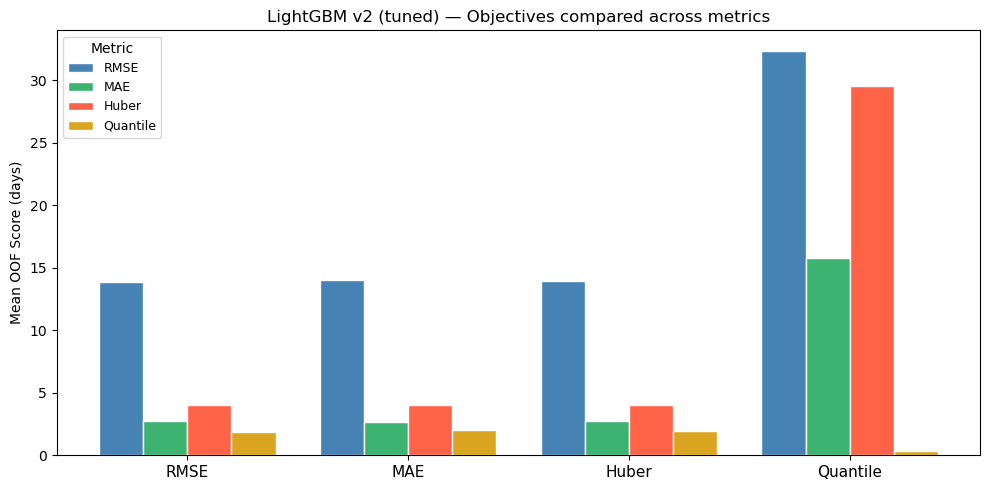

In [74]:
# Bar chart
metric_cols = scores.columns.tolist()
objectives  = scores.index.tolist()
x           = np.arange(len(objectives))
width       = 0.2
colors      = ["steelblue", "mediumseagreen", "tomato", "goldenrod"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (metric, color) in enumerate(zip(metric_cols, colors)):
    ax.bar(x + i * width, scores[metric].values, width, label=metric, color=color, edgecolor="white")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(objectives, fontsize=11)
ax.set_ylabel("Mean OOF Score (days)")
ax.set_title("LightGBM v2 (tuned) — Objectives compared across metrics")
ax.legend(title="Metric", fontsize=9)
plt.tight_layout()
plt.show()